<a href="https://colab.research.google.com/github/claranvt/Data-Analyst/blob/Python/KELOMPOK_5_TUBES_UAS_AI_MARKET_SEGMENTATION_(ALGORITMA_K_MEANS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# ⭐**TUGAS BESAR AI**⭐

**DATASET** : MARKET SEGGEMENTATION

 **METODE** : K-MEANS CLUSTERING

**TUJUAN**  : ANALISIS SEGMENTASI PASAR BERDASARKAN POLA PERILAKU PELANGGAN

**ANGGOTA KELOMPOK 5**
1. Zahra Talitha Putri                  (101012300192)

2. Rahma Aliyyah                        (101012300252)

3. Siti Rabiah Tuladawiah           (101012300304)

4. Aizza Kamelia Insani              (101012300341)

5. Clara Novita Fitriani                (101012330008)



In [ ]:
!pip install kneed
!pip install yellowbrick


**LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from yellowbrick.cluster import KElbowVisualizer
from IPython.display import display
from sklearn.pipeline import Pipeline

**DATASET  : MARKET SEGMENTATION**

In [ ]:
data = "https://raw.githubusercontent.com/zahratalitha/Market-Segmentations/refs/heads/main/Customer%20Data.csv"
df = pd.read_csv(data)


In [ ]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


⭐**DATA CLEANING**

In [ ]:
data_clean = df.drop(columns=["CUST_ID"])
print("Number of datapoints:", len(df))
data_clean.head()

Number of datapoints: 8950


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


⭐**EXPLORATION**

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [ ]:
data_clean.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


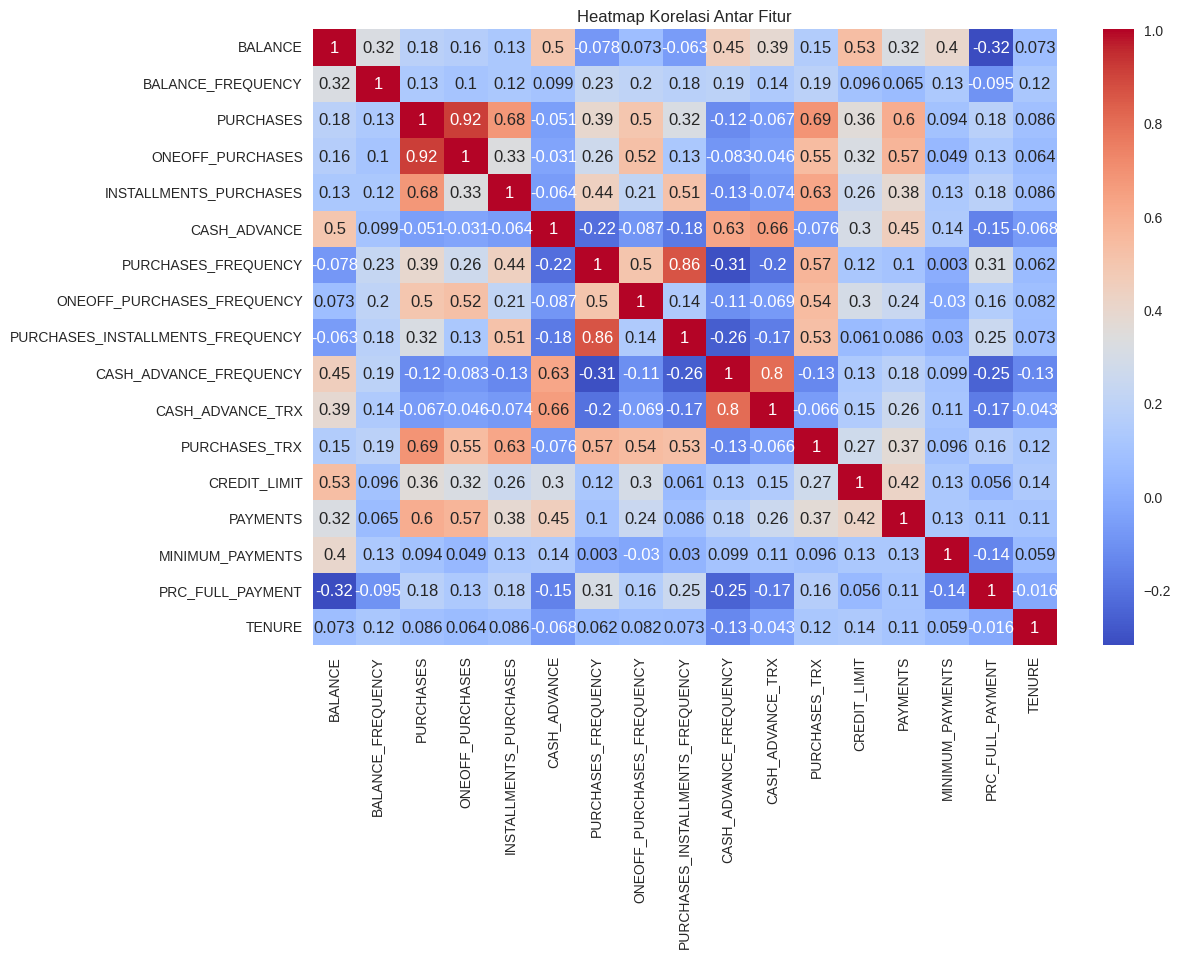

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data_clean.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

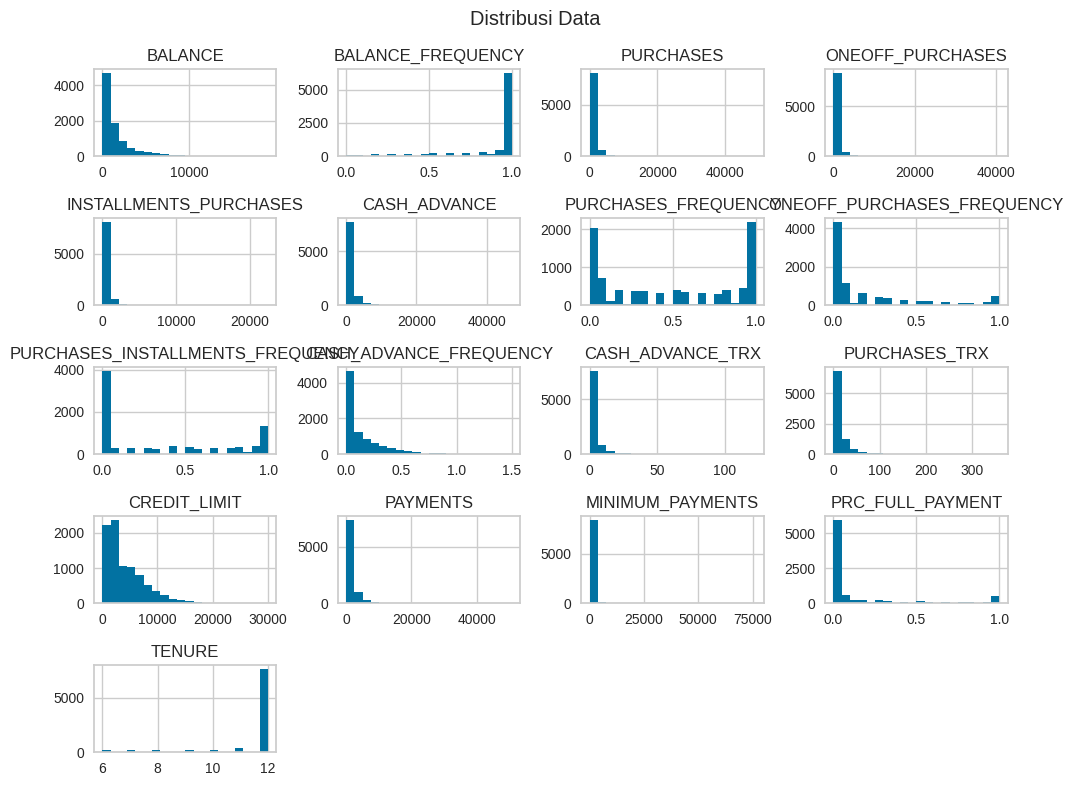

In [ ]:
data_clean.hist(bins=20, figsize=(10, 8))
plt.suptitle("Distribusi Data")
plt.tight_layout()
plt.show()

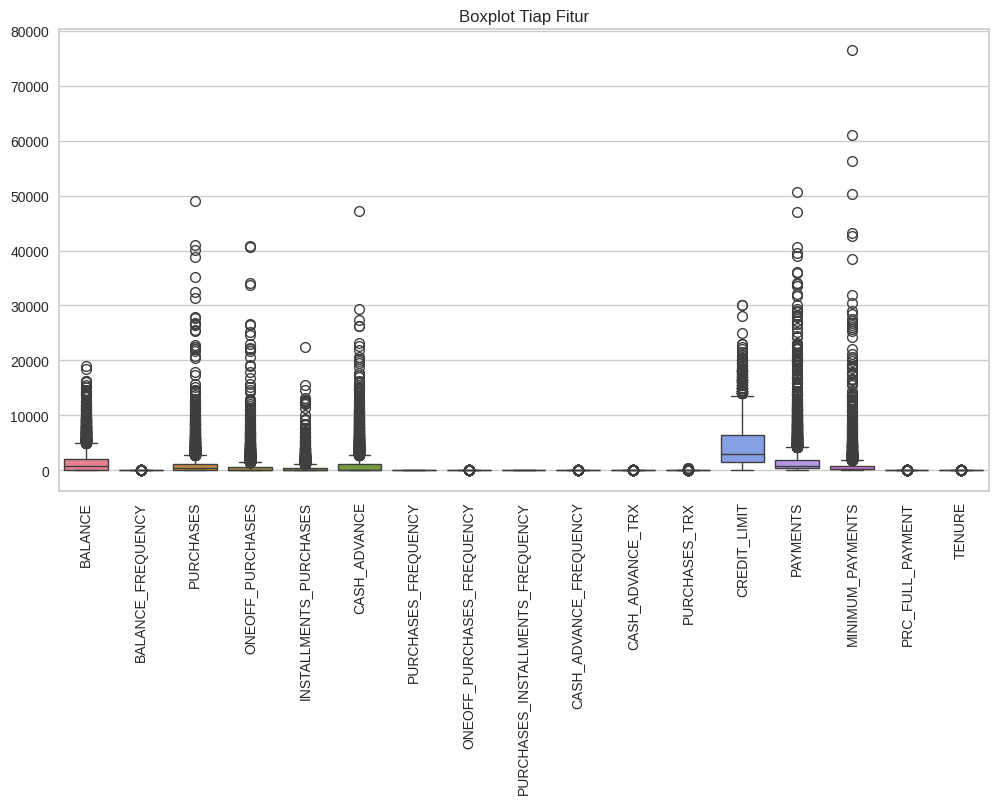

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data = data_clean)
plt.xticks(rotation=90)
plt.title("Boxplot Tiap Fitur")
plt.show()

⭐**REMOVING OUTLIERS**

In [ ]:
Q1 = data_clean.quantile(0.25)
Q3 = data_clean.quantile(0.75)
IQR = Q3 - Q1
data_no_outliers = data_clean[~((data_clean < (Q1 - 1.5 * IQR)) | (data_clean > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Jumlah data setelah menghapus outlier:", data_no_outliers.shape[0])

Jumlah data setelah menghapus outlier: 2994


⭐**PRE-PROCCESSING**

In [ ]:
# Imputasi nilai kosong pada data tanpa outlier
imputer = SimpleImputer(strategy='mean')
df_imputed_no_outliers = pd.DataFrame(imputer.fit_transform(data_no_outliers),
                                      columns=data_no_outliers.columns,
                                      index=data_no_outliers.index)

# Normalisasi/Scaling pada data tanpa outlier
scaler = StandardScaler()
data_scaled_no_outliers = scaler.fit_transform(df_imputed_no_outliers)
df_scaled_no_outliers = pd.DataFrame(data_scaled_no_outliers,
                                     columns=df_imputed_no_outliers.columns)
display(df_scaled_no_outliers.head())



,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.133600,-2.605506,-0.632613,-0.600900,-0.317151,-0.641837,-0.605044,-0.665870,-0.582952,-0.795323,-0.733337,-0.639048,-0.904793,-0.881709,-0.943177,-0.414442,0.0
1,-0.376303,0.339335,-0.811660,-0.552710,-0.689393,-0.641837,-0.828798,-0.183273,-0.805516,-0.795323,-0.733337,-0.752396,-0.822240,-0.197005,-0.642098,-0.414442,0.0
2,0.604361,0.339335,0.135888,-0.600900,1.012616,-0.641837,1.632485,-0.665870,1.865263,-0.795323,-0.733337,0.494429,-0.368198,-0.195955,0.179348,-0.414442,0.0
3,-0.184046,0.339335,1.094914,1.391436,0.090987,-0.641837,-0.157540,-0.183273,-0.137821,-0.795323,-0.733337,-0.299005,1.571799,-0.182717,-0.450001,-0.414442,0.0
4,1.529635,0.339335,-0.847739,-0.600900,-0.689393,-0.108188,-1.052550,-0.665870,-0.805516,-0.142048,-0.320706,-0.865744,-0.079263,-0.014075,1.488914,-0.414442,0.0


In [ ]:
#Mengecek jumlah nilai kosong (missing values / NaN)
print("Jumlah nilai unik per kolom:")
print(data_clean.nunique())

print("\nJumlah Missing Values (NaN):")
print(df_imputed_no_outliers .isnull().sum())


Jumlah nilai unik per kolom:
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

Jumlah Missing Values (NaN):
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PUR

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])
transformed_data = pipeline.fit_transform(df_imputed_no_outliers)


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(df_scaled_no_outliers)

print(df.shape)
print(data_scaled_no_outliers.shape)
print(len(cluster_labels))


(8950, 18)
(2994, 17)
2994


⭐ **DATA REDUCTION 3 COMPONENTS**

In [ ]:
pca = PCA(n_components=3)
pca.fit(df_scaled_no_outliers)
PCA_ds = pd.DataFrame(pca.transform(df_scaled_no_outliers), columns=(["col1","col2","col3"]))
PCA_ds.describe()


,col1,col2,col3
count,2994.000000,2.994000e+03,2.994000e+03
mean,0.000000,-7.594311e-17,8.543600e-17
std,2.223798,1.679075e+00,1.356429e+00
min,-4.697571,-3.735306e+00,-3.905270e+00
25%,-1.888065,-1.259257e+00,-8.625169e-01
50%,-0.196026,-2.554342e-01,-3.469727e-02
75%,1.725832,9.625929e-01,7.522196e-01
max,6.881958,8.391418e+00,4.242376e+00


**⭐ELBOW METHOD & SHILHOUETTE**

Elbow Method to determine the number of clusters to be formed:


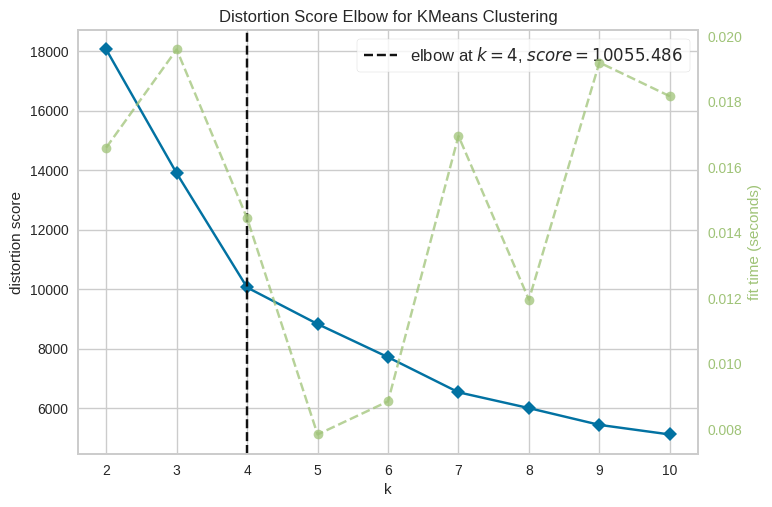

K terbaik dari Elbow: 4


In [ ]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

k_elbow= 4
print(f"K terbaik dari Elbow: {k_elbow}")

Number of clusters: 2, Silhouette Score: 0.36840935537969216
Number of clusters: 3, Silhouette Score: 0.31399755850679967
Number of clusters: 4, Silhouette Score: 0.35884455098429124
Number of clusters: 5, Silhouette Score: 0.36375826418940876
Number of clusters: 6, Silhouette Score: 0.362528247396297
Number of clusters: 7, Silhouette Score: 0.32792752476062415
Number of clusters: 8, Silhouette Score: 0.324191033864739
Number of clusters: 9, Silhouette Score: 0.3200742734292585
Number of clusters: 10, Silhouette Score: 0.32770585411441505


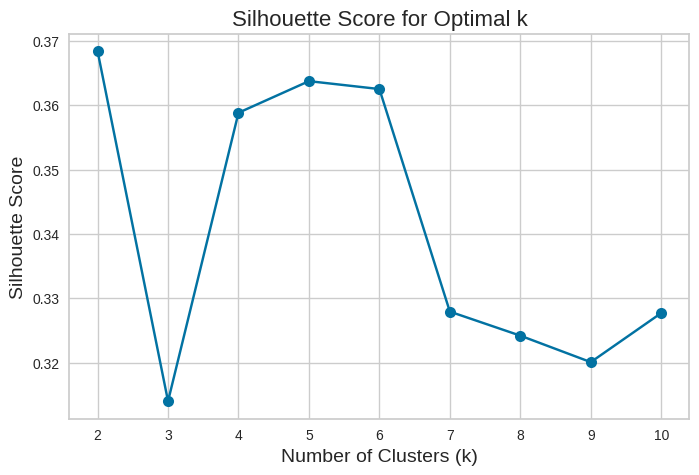

Silhouette Score terbaik: 0.3684
Cluster terbaik adalah k = 2


In [ ]:
range_n_clusters = range(2, 11)

silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(PCA_ds)
    score = silhouette_score(PCA_ds, cluster_labels)
    silhouette_scores.append(score)
    print(f'Number of clusters: {n_clusters}, Silhouette Score: {score}')

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Silhouette Score for Optimal k', fontsize=16)
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

best_k = list(range_n_clusters)[silhouette_scores.index(max(silhouette_scores))]
print(f"Silhouette Score terbaik: {max(silhouette_scores):.4f}")
print(f"Cluster terbaik adalah k = {best_k}")


**⭐VISUALISASI 2D (PCA)**

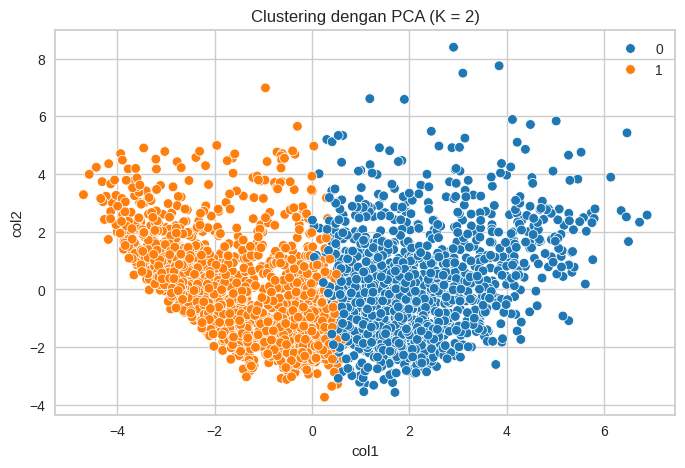

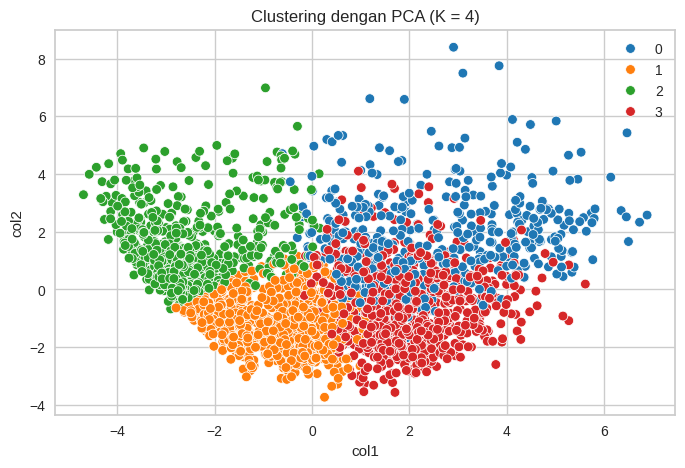

In [ ]:
for k in [2, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(PCA_ds)
    PCA_ds[f'Cluster_{k}'] = labels

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=PCA_ds['col1'], y=PCA_ds['col2'], hue=labels, palette='tab10')
    plt.title(f'Clustering dengan PCA (K = {k})')
    plt.show()


In [ ]:
#Covariance Matrix
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled_no_outliers)

cov_matrix = np.cov(pca_result.T)

print("Covariance Matrix dari hasil PCA:")
print(pd.DataFrame(cov_matrix, index=["PCA1", "PCA2"], columns=["PCA1", "PCA2"]))


Covariance Matrix dari hasil PCA:
              PCA1          PCA2
PCA1  4.945279e+00  1.139527e-15
PCA2  1.139527e-15  2.819291e+00


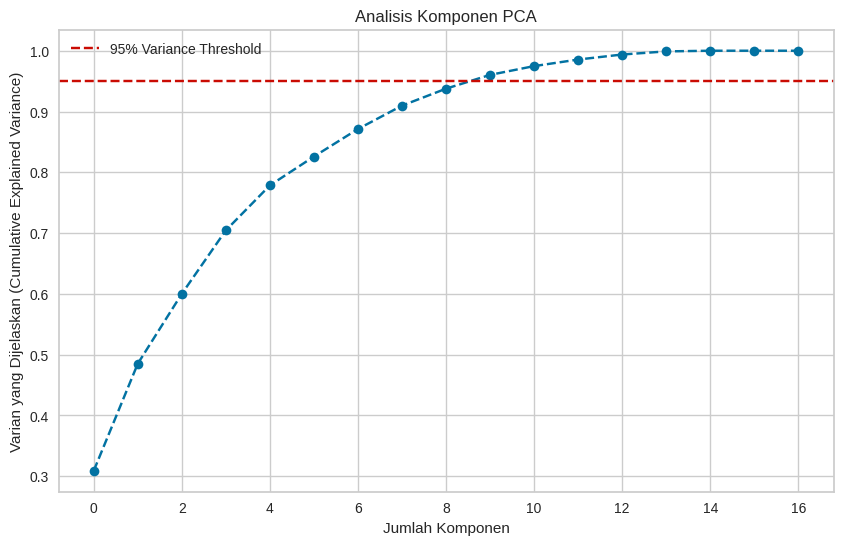

Jumlah komponen optimal: 10


In [ ]:
#ANALISIS KOMPONEN PCA
pca = PCA()
pca.fit(df_scaled_no_outliers)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Varian yang Dijelaskan (Cumulative Explained Variance)')
plt.title('Analisis Komponen PCA')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.legend()
plt.grid(True)
plt.show()

pca = PCA(n_components=0.95)
transformed_data = pca.fit_transform(df_scaled_no_outliers)
print(f"Jumlah komponen optimal: {pca.n_components_}")

In [ ]:
#CUMULATIVE VARIANCE
pca = PCA()
pca.fit(df_scaled_no_outliers)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_table = pd.DataFrame({
    "Komponen": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance (%)": np.round(explained_variance * 100, 2),
    "Cumulative Variance (%)": np.round(cumulative_variance * 100, 2)
})

print("Tabel Explained Variance per Komponen PCA:")
print(pca_table)

Tabel Explained Variance per Komponen PCA:
   Komponen  Explained Variance (%)  Cumulative Variance (%)
0       PC1                   30.90                    30.90
1       PC2                   17.61                    48.51
2       PC3                   11.50                    60.01
3       PC4                   10.44                    70.45
4       PC5                    7.39                    77.84
5       PC6                    4.74                    82.59
6       PC7                    4.53                    87.12
7       PC8                    3.85                    90.96
8       PC9                    2.79                    93.75
9      PC10                    2.27                    96.03
10     PC11                    1.44                    97.47
11     PC12                    1.08                    98.55
12     PC13                    0.83                    99.38
13     PC14                    0.51                    99.89
14     PC15                    0.11       

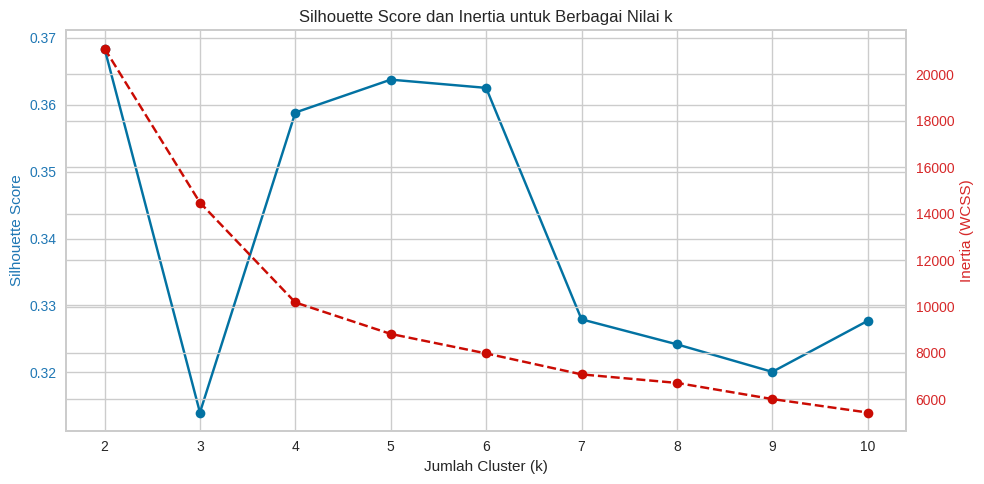

Inertia (variansi internal cluster): 5435.552419240272


In [ ]:
#INERTIA
inertias = []
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(PCA_ds)
    inertias.append(kmeans.inertia_)

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(range_n_clusters, silhouette_scores, 'bo-', label='Silhouette Score')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Inertia (WCSS)', color=color)
ax2.plot(range_n_clusters, inertias, 'ro--', label='Inertia')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Silhouette Score dan Inertia untuk Berbagai Nilai k')
fig.tight_layout()
plt.grid(True)
plt.show()

print("Inertia (variansi internal cluster):", kmeans.inertia_)



**⭐K-MEANS**

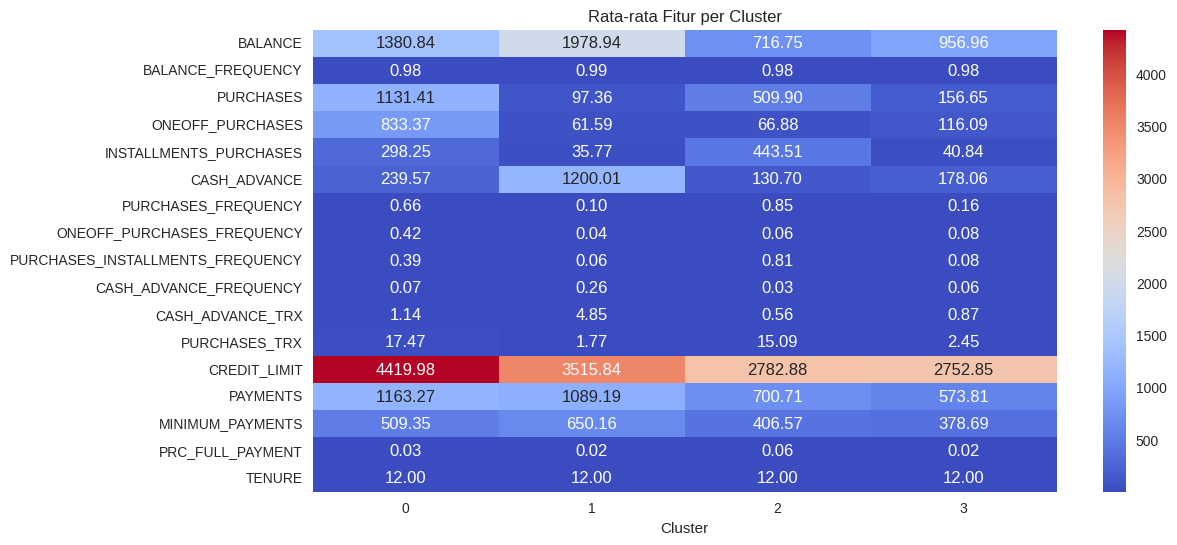


Cluster 0 (High Spenders):
- Pembelanja aktif dengan saldo tinggi (High Spender)
  Rata-rata PURCHASES: 1131.41
  Rata-rata BALANCE: 1380.84
  Rata-rata CASH_ADVANCE: 239.57
  Rata-rata TENURE: 12.00

Cluster 1 (Occasional Users):
- Pengguna yang tidak terlalu aktif, pembelian tidak terlalu sering
  Rata-rata PURCHASES: 97.36
  Rata-rata BALANCE: 1978.94
  Rata-rata CASH_ADVANCE: 1200.01
  Rata-rata TENURE: 12.00

Cluster 2 (Low Balance Users):
- Pelanggan dengan saldo rendah di akun mereka
  Rata-rata PURCHASES: 509.90
  Rata-rata BALANCE: 716.75
  Rata-rata CASH_ADVANCE: 130.70
  Rata-rata TENURE: 12.00

Cluster 3 (Frequent Installment Buyers):
- Pelanggan yang sering melakukan pembelian dengan metode cicilan atau angsuran
  Rata-rata PURCHASES: 156.65
  Rata-rata BALANCE: 956.96
  Rata-rata CASH_ADVANCE: 178.06
  Rata-rata TENURE: 12.00


In [ ]:

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(df_scaled_no_outliers)
df_imputed_no_outliers['Cluster'] = cluster_labels
cluster_means = df_imputed_no_outliers.groupby('Cluster').mean(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Rata-rata Fitur per Cluster')
plt.show()

cluster_label_dict = {
    0: 'High Spenders',
    1: 'Occasional Users',
    2: 'Low Balance Users',
    3: 'Frequent Installment Buyers',
}

for cluster_id, row in cluster_means.iterrows():
    label = cluster_label_dict.get(cluster_id, "Unknown")
    print(f"\nCluster {cluster_id} ({label}):")

    # Penjelasan detail berdasarkan fitur
    if label == 'High Spenders':
        print("- Pembelanja aktif dengan saldo tinggi (High Spender)")
    elif label == 'Occasional Users':
        print("- Pengguna yang tidak terlalu aktif, pembelian tidak terlalu sering")
    elif label == 'Low Balance Users':
        print("- Pelanggan dengan saldo rendah di akun mereka")
    elif label == 'Frequent Installment Buyers':
        print("- Pelanggan yang sering melakukan pembelian dengan metode cicilan atau angsuran")
    elif label == 'Average Users':
        print("- Pengguna dengan karakteristik rata-rata / seimbang")

    # Opsional: tambahan analisis numerik untuk memperkuat deskripsi
    print(f"  Rata-rata PURCHASES: {row['PURCHASES']:.2f}")
    print(f"  Rata-rata BALANCE: {row['BALANCE']:.2f}")
    print(f"  Rata-rata CASH_ADVANCE: {row['CASH_ADVANCE']:.2f}")
    print(f"  Rata-rata TENURE: {row['TENURE']:.2f}")


Konvergen pada iterasi ke-10


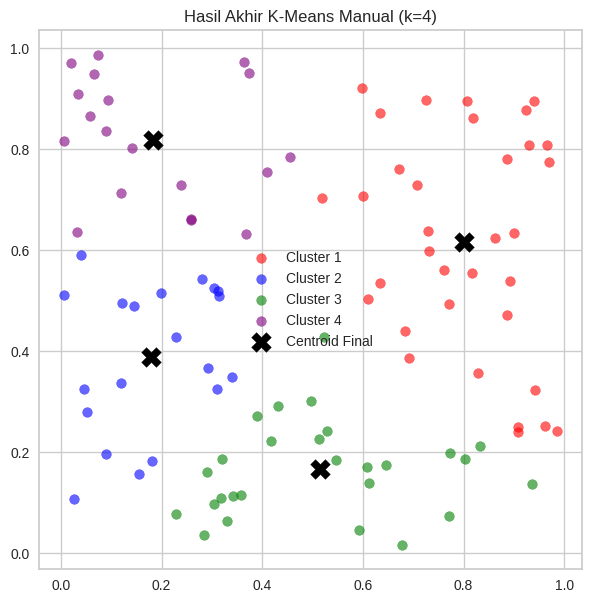

In [ ]:
np.random.seed(42)
data = np.random.rand(100, 2)
df = pd.DataFrame(data, columns=["x", "y"])

k = 4
random_indices = np.random.choice(len(df), size=k, replace=False)
centroids = df.iloc[random_indices].values

def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1)

max_iter = 100
for iteration in range(max_iter):
    distances = np.array([euclidean_distance(df.values, centroid) for centroid in centroids])
    cluster_labels = np.argmin(distances, axis=0)

    new_centroids = np.array([df.values[cluster_labels == i].mean(axis=0) for i in range(k)])

    if np.allclose(centroids, new_centroids):
        print(f"Konvergen pada iterasi ke-{iteration}")
        break

    centroids = new_centroids

plt.figure(figsize=(7, 7))
colors = ['red', 'blue', 'green', 'purple', 'yellow']
for i in range(k):
    cluster_data = df.values[cluster_labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], color=colors[i], label=f"Cluster {i+1}", alpha=0.6)

plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroid Final')
plt.title(f"Hasil Akhir K-Means Manual (k={k})")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("Nilai unik di kolom Cluster:", df_imputed_no_outliers['Cluster'].unique())
print("Keys di cluster_labels_dict:", cluster_label_dict.keys())


Nilai unik di kolom Cluster: [3 2 1 0]
Keys di cluster_labels_dict: dict_keys([0, 1, 2, 3])


Semua nilai cluster sudah ada labelnya.


,Cluster,Segment
0,3,Frequent Installment Buyers
4,3,Frequent Installment Buyers
7,2,Low Balance Users
8,3,Frequent Installment Buyers
14,3,Frequent Installment Buyers


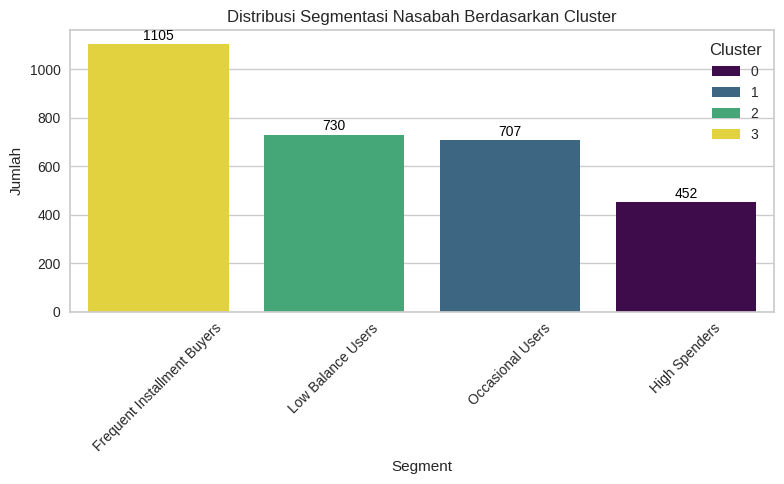

In [ ]:

#Mengelompokkan data ke dalam 4 kelompok berdasarkan fitur yang sudah diskalakan, lalu menyimpan hasil pengelompokan tersebut ke dataframe

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(df_scaled_no_outliers)

df_imputed_no_outliers = df_imputed_no_outliers.copy()
df_imputed_no_outliers['Cluster'] = cluster_labels

# 2. Buat dictionary label cluster
cluster_label_dict = {
    0: 'High Spenders',
    1: 'Occasional Users',
    2: 'Low Balance Users',
    3: 'Frequent Installment Buyers',
}

# 3. Cek apakah semua cluster sudah ada labelnya
unmapped_values = df_imputed_no_outliers['Cluster'][~df_imputed_no_outliers['Cluster'].isin(cluster_label_dict.keys())]
if not unmapped_values.empty:
    print(f"Nilai berikut tidak dapat dimapping: {unmapped_values.unique()}")
else:
    print("Semua nilai cluster sudah ada labelnya.")

# 4. Mapping cluster ke segmentasi dengan dictionary label
df_imputed_no_outliers['Segment'] = df_imputed_no_outliers['Cluster'].map(cluster_label_dict)

# 5. Salin dataframe final
final_df = df_imputed_no_outliers.copy()

# 6. Tampilkan data
display(final_df[['Cluster', 'Segment']].head())

# 7. Plot distribusi segmentasi

cluster_counts = final_df['Segment'].value_counts()
plt.figure(figsize=(8, 5))
sns.countplot(x='Segment', hue='Cluster', data=final_df, palette='viridis')

for i, count in enumerate(cluster_counts):
    plt.text(i, count + 5, f"{count}", ha='center', va='bottom', fontsize=10, color='black')
plt.title("Distribusi Segmentasi Nasabah Berdasarkan Cluster")
plt.xlabel("Segment")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()




In [ ]:
final_df.loc[[0, 4, 7, 8, 14]]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster,Segment
0,40.900749,0.818182,95.40,0.00,95.4,0.00000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.0,12.0,3,Frequent Installment Buyers
4,817.714335,1.000000,16.00,16.00,0.0,0.00000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.0,12.0,3,Frequent Installment Buyers
7,1823.652743,1.000000,436.20,0.00,436.2,0.00000,1.000000,0.000000,1.000000,0.000000,0.0,12.0,2300.0,679.065082,532.033990,0.0,12.0,2,Low Balance Users
8,1014.926473,1.000000,861.49,661.49,200.0,0.00000,0.333333,0.083333,0.250000,0.000000,0.0,5.0,7000.0,688.278568,311.963409,0.0,12.0,3,Frequent Installment Buyers
14,2772.772734,1.000000,0.00,0.00,0.0,346.81139,0.000000,0.000000,0.000000,0.083333,1.0,0.0,3000.0,805.647974,989.962866,0.0,12.0,3,Frequent Installment Buyers


In [ ]:
final_df = df_imputed_no_outliers.copy()

# label cluster hasil K-Means
final_df['Cluster'] = cluster_labels

# Simpan ke file CSV jika diperlukan
final_df.to_csv('final_kmeans_clusters.csv', index=False)
print("Hasil clustering disimpan ke 'final_kmeans_clusters.csv'")

Hasil clustering disimpan ke 'final_kmeans_clusters.csv'
